<div style="border:4px solid red; padding:10px">

For all homework blocks that have numerical answers, name the variable the hw plus the homework number.

</div>

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

# Review
<details open>
<summary>Click to collapse</summary>

The Sommerfeld diffraction integral is

$E(P_o) = \frac{z}{j\lambda} \int_{\Sigma} E_{inc} \frac{e^{jkr_{01}}}{r_{01}^2} dx' dy'$


The Fresnel diffraction equation is

$E(x,y,z) = \frac{e^{jkz}}{j\lambda z} 
\iint_{\Sigma} E(x',y') 
\exp\left[j\frac{k}{2z}\left((x-x')^2 + (y-y')^2\right)\right]
dx' dy'$


The Fresnel diffraction at focus of lens

$E(x,y,z) = \iint_{\Sigma} E_o(x',y')  
\exp \left( -j\frac{2 \pi}{ \lambda  f} \left(x  x' \right) \right) dx' \exp \left( -j\frac{2 \pi}{ \lambda  f} \left(y  y' \right) \right) dx' dy'$


Thus, at the focus of the lens the diffraction pattern can be solved using Fourier transforms with the relationships of

$f_x = \frac{x}{\lambda f}, \quad f_y = \frac{y}{\lambda f}$


The Fraunhoffer diffraction equation is 

$E(x,y,z) =
\frac{e^{jkz}}{j\lambda z} e^{j\frac{k}{2z}(x^2+y^2)}
\iint_{\Sigma} E(x',y')
\exp\left[-j\frac{k}{z}(xx' + yy')\right] dx' dy'$

$E(x,y,z) = \left( \mathcal{F}_x \{ E(x') \} \right) \left( \mathcal{F}_y \{ E(y') \} \right)$

with $f_x=\frac{x}{\lambda z}$ and $f_y=\frac{y}{\lambda z}$

## Basic Fourier Transform Relations


If $f(x) \leftrightarrow F(f)$:

-   $K f(x) \leftrightarrow K F(f)$
-   $f(ax) \leftrightarrow \frac{1}{|a|} F\!\left(\frac{f}{a}\right)$
-   $f(x-x_0) \leftrightarrow F(f)e^{-j2\pi f x_0}$
-   $e^{j2\pi f_0 x} f(x) \leftrightarrow F(f-f_0)$

## Fourier Transform Pairs

| Function | Fourier Transform |
|-----------|------------------|
| $\delta(x)$ | $1$ |
| $A$ | $2\pi A\delta(f)$ |
| $\cos(\omega_0 x)$ | $\pi[\delta(f-\omega_0)+\delta(f+\omega_0)]$ |
| $\sin(\omega_0 x)$ | $j\pi[\delta(f-\omega_0)-\delta(f+\omega_0)]$ |
| $\text{rect}(x)$ | $\text{sinc}(f)$ |
| $\Lambda(x)$ | $\text{sinc}^2(f)$ |
| $\text{circ}(r/R)$ | $\pi R^2 \dfrac{J_1(2\pi R f)}{2\pi R f}$ |
| $e^{-\pi x^2}$ | $e^{-\pi f^2}$ |
| $e^{j\pi x^2}$ | $e^{j\pi/4} e^{-j\pi f^2}$ |
| $\sum_{n=-S}^{S}\delta(x-n)$ | $\dfrac{\sin(M\pi f)}{\sin(\pi f)}$, $M=2S+1$ |
| $\sum_{n=-\infty}^{\infty}\delta(x-n)$ | $\sum_{n=-\infty}^{\infty}\delta(f-n)$ |


$\text{rect}(x) = \begin{cases}
1 & |x| \le \frac{1}{2} \\
0 & \text{otherwise}
\end{cases}$

$\text{sinc}(x)=\frac{\sin (\pi x)}{\pi x}$

$\Lambda(x) = \begin{cases}
1-|x| & |x| \le 1 \\
0 & \text{otherwise}
\end{cases}$

$\text{circ}\left(\sqrt{x^2 + y^2}\right) = \begin{cases}
1 & \sqrt{x^2 + y^2} \le 1 \\
0 & \text{otherwise}
\end{cases}$

$\int_{-\infty}^{\infty} \mathrm{sinc}(x) dx = 1$

$\int_{-\infty}^{\infty} \mathrm{sinc}^2(x) dx = 1$

$\int_{0}^{\infty} \left| \frac{J_1(x)}{x} \right|^2 dx = \frac{4}{3\pi}$

$\int_{0}^{\infty} x \left| \frac{J_1(x)}{x} \right|^2 dx = \frac{1}{2}$

## Grating

1. Grating order direction: $\sin\theta_m = \sin\theta_i + m\frac{\lambda}{\Lambda}$
2. Efficiency of each order: $\eta_m = A \left( f_x=\frac{m}{\Lambda} \right)$
3. Shape of each order: Same as if there was no grating

</details>

<div style="border:4px solid red; padding:10px">

**HW1:** You are designing an optical system to be used as part of a laser drilling system. The system uses a femtosecond laser with wavelength of $\lambda=515nm$, is a Gaussian beam with a FWHM=2mm, has a Gaussian pulse with a FWHM of 300 fs, has a repetition rate of 10kHz, and an average power of 1W. What is the energy in a single pulse in units of joule? 

In [36]:
#HW1 CODE
P_avg = 1 #W or J/S
f_pulse = 10e3 #Hz

E_pulse = P_avg / f_pulse #J
print(f"Energy per pulse: {E_pulse:.2e} J")
hw1 = E_pulse




Energy per pulse: 1.00e-04 J


<div style="border:4px solid red; padding:10px">

**HW2:** You are designing an optical system to be used as part of a laser drilling system. The system uses a femtosecond laser with wavelength of $\lambda=515nm$, is a Gaussian beam with a FWHM=2mm, has a Gaussian pulse with a FWHM of 300 fs, has a repetition rate of 10kHz, and an average power of 1W. The pulse has a temporal response given by $P(t) = P_o \exp \left( - \left( \frac{t−\frac{n}{10^4}}{\sigma} \right)^2 \right)$.  What is the peak power of the laser pulse (the value of P_o) in units of watts?  Create a plot of the pulse as a function of time.

Pulse energy: 1.00e-04 J
Pulse sigma: 1.80e-13 s
Peak power: 313145759.57 W


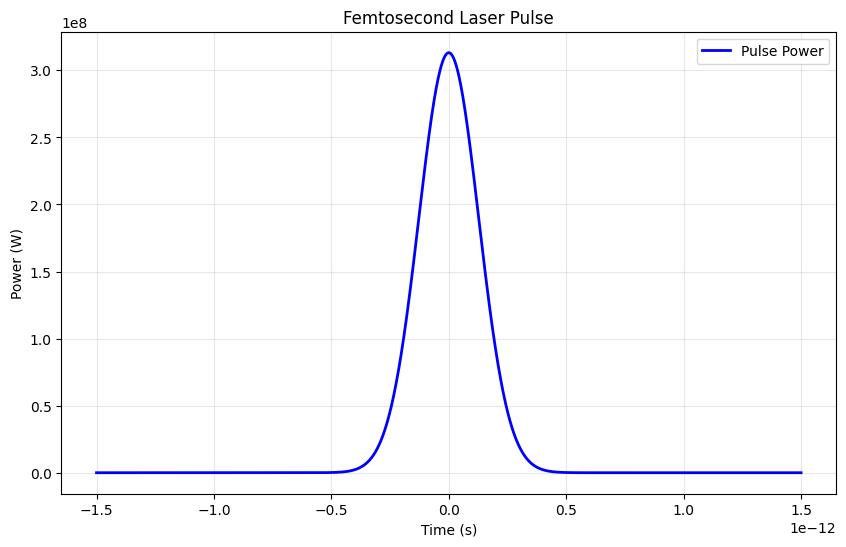

In [37]:
#HW2 CODE
FWHM_Pulse = 300e-15 # s
f_pulse = 10e3 # Hz
P_avg = 1 # W

# This Gaussian uses exp(-(t/sigma)^2), so FWHM = 2*sigma*sqrt(ln(2))
sigma_pulse = FWHM_Pulse / (2 * np.sqrt(np.log(2))) # s
E_pulse = P_avg / f_pulse # J
P_0 = E_pulse / (sigma_pulse * np.sqrt(np.pi)) # W

print(f"Pulse energy: {E_pulse:.2e} J")
print(f"Pulse sigma: {sigma_pulse:.2e} s")
print(f"Peak power: {P_0:.2f} W")

n = 0   #This is pulse #, not an index
t0 = n / f_pulse # s
t = np.linspace(t0 - 5 * FWHM_Pulse, t0 + 5 * FWHM_Pulse, 2000) # s
P_t = P_0 * np.exp(-(((t - t0) / sigma_pulse) ** 2)) # W

plt.figure(figsize=(10, 6))
plt.plot(t, P_t, 'b-', linewidth=2, label='Pulse Power')
plt.xlabel('Time (s)')
plt.ylabel('Power (W)')
plt.title('Femtosecond Laser Pulse')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

hw2 = P_0


<div style="border:4px solid red; padding:10px">

**HW3:** You are designing an optical system to be used as part of a laser drilling system. The system uses a femtosecond laser with wavelength of $\lambda=515nm$, is a Gaussian beam with a FWHM=4mm, has a Gaussian pulse with a FWHM of 300 fs, has a repetition rate of 10kHz, and an average power of 1W. The laser beam profile is given by $I=I_o \exp \left( - \left( \frac{x}{W_1}\right)^2 \right)$.  What is the value of $W_1$ in units of meters?

In [38]:
#HW3 CODE
FWHM_beam = 4e-3 # m

# I(x) = I0 * exp(-(x/W1)^2) => FWHM = 2 * W1 * sqrt(ln(2))
W1 = FWHM_beam / (2 * np.sqrt(np.log(2)))
hw3 = W1
print(f"W1 = {hw3:.10e} m")

W1 = 2.4022448176e-03 m


<div style="border:4px solid red; padding:10px">

**HW4:** You are designing an optical system to be used as part of a laser drilling system. The system uses a femtosecond laser with wavelength of $\lambda=515nm$, is a Gaussian beam with a FWHM=4mm, has a Gaussian pulse with a FWHM of 300 fs, has a repetition rate of 10kHz, and$ an average power of 1W. The laser beam profile is given by $I=I_1 \exp \left( - \left( \frac{x}{W_1}\right)^2 \right)$.  What is the peak irradiance (value of $I_1$) in units of $\frac{W}{m^2}$?

In [39]:
#HW4 CODE
FWHM_Pulse = 300e-15 # s
f_pulse = 10e3 # Hz
P_avg = 1 # W
FWHM_beam = 4e-3 # m

# Temporal Gaussian: P(t) = P0 * exp(-(t/sigma)^2)
sigma_pulse = FWHM_Pulse / (2 * np.sqrt(np.log(2)))
E_pulse = P_avg / f_pulse
P_0 = E_pulse / (sigma_pulse * np.sqrt(np.pi)) # W

# Spatial Gaussian (2D): I(x,y) = I1 * exp(-(x^2+y^2)/W1^2)
W1 = FWHM_beam / (2 * np.sqrt(np.log(2)))
I_1 = P_0 / (np.pi * W1**2) # W/m^2

hw4 = I_1
print(f"Peak irradiance I1 = {hw4:.10e} W/m^2")

Peak irradiance I1 = 1.7272775649e+13 W/m^2


In [40]:
def fwhm_with_bounds(x_positions, values):
    peak_idx = np.argmax(values)
    half_max = 0.5 * values[peak_idx]

    def _interp(x1, y1, x2, y2):
        if y2 == y1:
            return x1
        return x1 + (half_max - y1) * (x2 - x1) / (y2 - y1)

    left = right = None
    for idx in range(peak_idx, 0, -1):
        y_low = values[idx - 1]
        y_high = values[idx]
        if y_low <= half_max <= y_high:
            left = _interp(x_positions[idx - 1], y_low, x_positions[idx], y_high)
            break

    for idx in range(peak_idx, len(values) - 1):
        y_high = values[idx]
        y_low = values[idx + 1]
        if y_high >= half_max >= y_low:
            right = _interp(x_positions[idx], y_high, x_positions[idx + 1], y_low)
            break

    if left is None or right is None:
        return np.nan, np.nan, np.nan

    return right - left, left, right

<div style="border:4px solid red; padding:10px">

**HW5:** You are designing an optical system to be used as part of a laser drilling system. The system uses a femtosecond laser with wavelength of $\lambda=515nm$, is a Gaussian beam with a FWHM=4mm, has a Gaussian pulse with a FWHM of 300 fs, has a repetition rate of 10kHz, and an average power of 1W. The laser beam profile is given by $I=I_1 \exp \left( - \left( \frac{x}{W_1}\right)^2 \right)$.  The laser is focused by a 100X microscope objective.  The microscope objective is modeled as an ideal lens with a focal length of $f=2mm$.  What is the FWHM of the focal spot in units of meters?


In [41]:
#HW5 CODE
lam = 515e-9
f = 2e-3
W_focal = (lam * f) / (np.pi * W1)  # intensity width parameter at focus
FWHM_focal = W_focal * 2 * np.sqrt(np.log(2))
hw5 = FWHM_focal
print(f"FWHM of focused beam: {hw5:.10e} m")

FWHM of focused beam: 2.2725466816e-07 m


<div style="border:4px solid red; padding:10px">

**HW6:** You are designing an optical system to be used as part of a laser drilling system. The system uses a femtosecond laser with wavelength of $\lambda=515nm$, is a Gaussian beam with a FWHM=4mm, has a Gaussian pulse with a FWHM of 300 fs, has a repetition rate of 10kHz, and an average power of 1W. The laser beam profile is given by $I=I_1 \exp \left( - \left( \frac{x}{W_1}\right)^2 \right)$.  The laser is focused by a 100X microscope objective.  The microscope objective is modeled as an ideal lens with a focal length of $f=2mm$ and entrance pupil with a diameter of $4mm$.  What is the FWHM of the focal spot in units of meters?  Solve the problem by multiplying the Gaussian by a circ function.  The solution will be a Gaussian convolved by a Jinc function. Create a 2D line plot of the profile.

FWHM of focused beam with pupil: 3.3984290752e-07 m


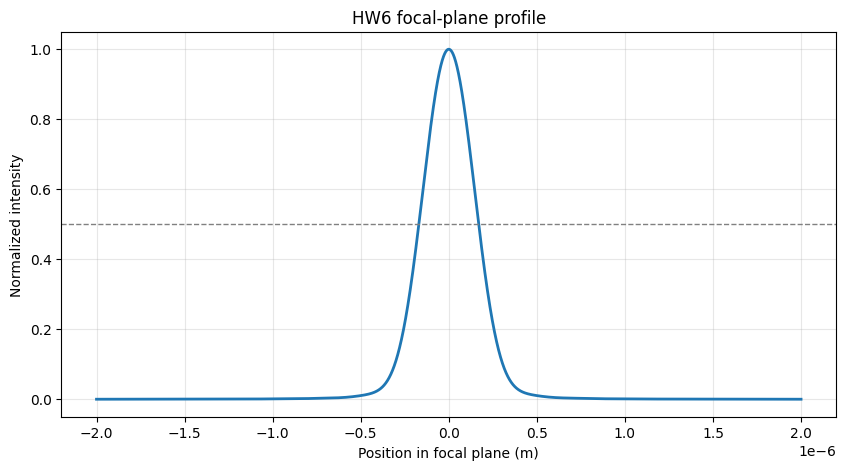

In [42]:
#HW6 CODE
f = 2e-3
aperture_radius = 2e-3  # 4 mm diameter pupil

# Focal-plane coordinate in meters
x_focus = np.linspace(-2e-6, 2e-6, 8001)
dx = x_focus[1] - x_focus[0]

# Gaussian focal spot width from HW5
sigma_focus = (lam * f) / (np.pi * W1)
gaussian_focal = np.exp(-((x_focus / sigma_focus) ** 2))

# Airy/Jinc intensity from the circular pupil
u = (2 * np.pi * aperture_radius * x_focus) / (lam * f)
jinc_focal = np.ones_like(u)
nonzero = u != 0
jinc_focal[nonzero] = (2 * special.j1(u[nonzero]) / u[nonzero]) ** 2

# Convolution of the Gaussian profile with the Jinc profile
I_pupil_focal = np.convolve(gaussian_focal, jinc_focal, mode='same') * dx
I_pupil_focal /= np.max(I_pupil_focal)

FWHM_pupil_focal, left_bound, right_bound = fwhm_with_bounds(x_focus, I_pupil_focal)
hw6 = FWHM_pupil_focal

print(f"FWHM of focused beam with pupil: {hw6:.10e} m")

plt.figure(figsize=(10, 5))
plt.plot(x_focus, I_pupil_focal, linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Position in focal plane (m)')
plt.ylabel('Normalized intensity')
plt.title('HW6 focal-plane profile')
plt.grid(True, alpha=0.3)
plt.show()

<div style="border:4px solid red; padding:10px">

**HW7:** You are designing an optical system to be used as part of a laser drilling system. The system uses a femtosecond laser with wavelength of $\lambda=515nm$, is a Gaussian beam with a FWHM=4mm, has a Gaussian pulse with a FWHM of 300 fs, has a repetition rate of 10kHz, and an average power of 1W. The laser beam profile is given by $I=I_1 \exp \left( - \left( \frac{x}{W_1}\right)^2 \right)$.  The laser is focused by a 100X microscope objective.  The microscope objective is modeled as an ideal lens with a focal length of $f=2mm$ and entrance pupil with a diameter of $4mm$.  What is the peak irradiance of the focal spot in units of $\frac{W}{m^2}$? 

In [43]:
#HW7 CODE
# Peak irradiance using a circularly symmetric Hankel-transform model

f = 2e-3
aperture_radius = 2e-3

# Radial coordinates in image and pupil planes (meters)
r_focus = np.linspace(0, 4e-6, 4001)
r_pupil = np.linspace(0, aperture_radius, 4001)
dr_pupil = r_pupil[1] - r_pupil[0]

# Input intensity: I(r)=I1*exp(-(r/W1)^2) -> field amplitude ~ exp(-(r/W1)^2/2)
E_pupil = np.exp(-0.5 * (r_pupil / W1) ** 2)

# Fraunhofer focus of a circularly symmetric field is a 0th-order Hankel transform
arg = (2 * np.pi / (lam * f)) * np.outer(r_focus, r_pupil)
J0 = special.j0(arg)
E_focus = J0 @ (E_pupil * r_pupil) * dr_pupil

# Normalized focal irradiance profile
I_norm = np.abs(E_focus) ** 2
I_norm /= np.max(I_norm)

# Power transmitted by the finite pupil
power_transmission = 1 - np.exp(-(aperture_radius / W1) ** 2)
P_transmitted = P_0 * power_transmission

# Effective area from normalized radial profile: A_eff = 2*pi*integral I_norm(r)*r dr
A_eff = 2 * np.pi * np.trapezoid(I_norm * r_focus, r_focus)

I_focus_hw7 = P_transmitted / A_eff
hw7 = I_focus_hw7
print(f"Peak irradiance at focus: {hw7:.10e} W/m^2")

Peak irradiance at focus: 1.8536557308e+21 W/m^2


<div style="border:4px solid red; padding:10px">

**HW8:** You are designing an optical system to be used as part of a laser drilling system. The system uses a femtosecond laser with wavelength of $\lambda=515nm$, is a Gaussian beam with a FWHM=4mm, has a Gaussian pulse with a FWHM of 300 fs, has a repetition rate of 10kHz, and an average power of 1W. The laser beam profile is given by $I=I_1 \exp \left( - \left( \frac{x}{W_1}\right)^2 \right)$.  The laser is focused by a 100X microscope objective.  The microscope objective is modeled as an ideal lens with a focal length of $f=2mm$ and entrance pupil with a diameter of $4mm$.  What is the peak irradiance of the side lobes in units of $\frac{W}{m^2}$? 

In [44]:
#HW8 CODE
# Use the first circular side lobe: first local maximum after the first local minimum
y = I_norm
r = r_focus

dy = np.diff(y)
min_idxs = np.where((dy[:-1] < 0) & (dy[1:] > 0))[0] + 1
max_idxs = np.where((dy[:-1] > 0) & (dy[1:] < 0))[0] + 1

if min_idxs.size == 0:
    first_sidelobe_location = np.nan
    first_sidelobe_norm = np.nan
    first_sidelobe_irradiance = np.nan
else:
    min_after_center = min_idxs[0]
    max_after_min = max_idxs[max_idxs > min_after_center]

    if max_after_min.size == 0:
        first_sidelobe_location = np.nan
        first_sidelobe_norm = np.nan
        first_sidelobe_irradiance = np.nan
    else:
        i1 = max_after_min[0]
        first_sidelobe_location = r[i1]
        first_sidelobe_norm = y[i1]
        first_sidelobe_irradiance = I_focus_hw7 * first_sidelobe_norm

print(f"First side-lobe location: {first_sidelobe_location:.6e} m")
print(f"Normalized side-lobe peak: {first_sidelobe_norm:.6e}")
print(f"First side-lobe irradiance: {first_sidelobe_irradiance:.6e} W/m^2")

hw8 = first_sidelobe_irradiance

First side-lobe location: 4.330000e-07 m
Normalized side-lobe peak: 1.200192e-02
First side-lobe irradiance: 2.224742e+19 W/m^2


<div style="border:4px solid red; padding:10px">

**HW9:** You are designing an optical system to be used as part of a laser drilling system. The system uses a femtosecond laser with wavelength of $\lambda=515nm$, is a Gaussian beam with a FWHM=4mm, has a Gaussian pulse with a FWHM of 300 fs, has a repetition rate of 10kHz, and an average power of 1W. The laser beam profile is given by $I=I_1 \exp \left( - \left( \frac{x}{W_1}\right)^2 \right)$.  The laser is focused by a 100X microscope objective.  The microscope objective is modeled as an ideal lens with a focal length of $f=2mm$ and entrance pupil with a diameter of $4mm$. Immediately in front of the lens you place a diffraction grating.  The diffraction grating is designed to create 11 beams separated by $3 \mu m$.  What is the grating period in units of meters?  Remember that the lens is an ideal lens.  This means that the paraxial approximation is valid. 

In [45]:
#HW9 CODE
f = 2e-3
order_spacing = 3e-6 # m
lam = 515e-9 # m
theta_1 = np.arctan2(order_spacing, f)
m = 1
d = m * lam / theta_1
hw9 = d
print(f"Grating period d: {hw9:.10e} m")


Grating period d: 3.4333359083e-04 m


In [46]:
def grating_calc(val):
    m_max = 30
    lam = 0.515e-6
    n = 1.5

    d = val[0]
    xf = np.asarray(val[1:], dtype=float)
    widths = np.diff(xf)
    centers = (xf[:-1] + xf[1:]) / 2
    period = xf[-1]

    phases = np.array([
        np.exp(1j * n * 2 * np.pi * d / lam) if i % 2 == 0
        else np.exp(1j * 2 * np.pi * d / lam)
        for i in range(len(widths))
    ])

    orders = np.arange(-m_max, m_max + 1)
    amp = np.array([
        np.sum(
            phases
            * widths
            * np.sinc(widths * order / period)
            * np.exp(-1j * 2 * np.pi * order * centers / period)
        )
        for order in orders
    ])

    eff = np.abs(amp) ** 2
    max_eff = np.max(eff)
    # Handle case where max is 0 or NaN to prevent invalid results
    if max_eff <= 0 or np.isnan(max_eff):
        return np.full(len(eff), np.nan)
    eff = eff / max_eff  # Normalize without rounding to preserve precision
    return eff

<div style="border:4px solid red; padding:10px">

**HW10:** You are designing an optical system to be used as part of a laser drilling system. The system uses a femtosecond laser with wavelength of $\lambda=515nm$, is a Gaussian beam with a FWHM=4mm, has a Gaussian pulse with a FWHM of 300 fs, has a repetition rate of 10kHz, and an average power of 1W. The laser beam profile is given by $I=I_1 \exp \left( - \left( \frac{x}{W_1}\right)^2 \right)$.  The laser is focused by a 100X microscope objective.  The microscope objective is modeled as an ideal lens with a focal length of $f=2mm$ and entrance pupil with a diameter of $4mm$. Immediately in front of the lens you place a diffraction grating.  The diffraction grating is designed to create 11 beams separated by $3 \mu m$.  Design the grating period.  
- Refractive index of the grating substrate: $n=1.5$
- The aspect ratio is $ratio=\frac{d}{min(diff(x))}$. Aspect ratio must be less than 5.
- Variation of center 11 beams less than 5% $ \frac{max \left( \eta_{-11}:\eta_{+11} \right) - min \left( \eta_{-11}:\eta_{+11} \right)}{max \left( \eta_{-11}:\eta_{+11} \right)} <0.05 $
- Total power in orders from m=-6 to m=-30 plus power in orders m=6 to m=30 less than 10% of the total power
- hw10 = np.array([d, x]) (d is the grating depth and x are the transition points of the grating.  The first element of x must be 0 and the last element of x must be the grating period)
- The grating starts with a ridge.

In [47]:
# def grating_calc(val):
#     m_max = 30
#     lam = 0.515e-6
#     n = 1.5

#     d = val[0]
#     xf = np.asarray(val[1:], dtype=float)
#     widths = np.diff(xf)
#     centers = (xf[:-1] + xf[1:]) / 2
#     period = xf[-1]

#     if period <= 0 or np.any(widths <= 0):
#         return np.full(2 * m_max + 1, np.nan)

#     phase_base = 2 * np.pi * d / lam
#     phase_even = np.exp(1j * n * phase_base)
#     phase_odd = np.exp(1j * phase_base)
#     phases = np.where(np.arange(widths.size) % 2 == 0, phase_even, phase_odd)

#     orders = np.arange(-m_max, m_max + 1)
#     k = (orders[:, None] / period)
#     sinc_term = np.sinc(widths[None, :] * k)
#     phase_term = np.exp(-1j * 2 * np.pi * centers[None, :] * k)
#     amp = np.sum((phases * widths)[None, :] * sinc_term * phase_term, axis=1)

#     eff = np.abs(amp) ** 2
#     max_eff = np.max(eff)
#     if max_eff <= 0 or np.isnan(max_eff):
#         return np.full(len(eff), np.nan)
#     eff = eff / max_eff  # Normalize without rounding
#     return eff

# from scipy.optimize import differential_evolution, minimize, dual_annealing

# lambda_nm = 515.0
# lambda_m = lambda_nm * 1e-9
# beam_spacing = 3e-6
# focal_length = 2e-3
# period = focal_length * lambda_m / beam_spacing
# m_max = 30
# center_slice = slice(m_max - 5, m_max + 6)
# orders = np.arange(-m_max, m_max + 1)
# n_transitions = 12  # editable: total number of transition points including 0 and period
# if n_transitions < 2:
#     raise ValueError("n_transitions must be at least 2")
# n_sections = n_transitions - 1

# def build_val(params):
#     """Convert optimizer params [depth, w1, w2, ..., wN] to [depth, x0, x1, ..., xN]."""
#     depth = params[0]
#     raw_widths = np.clip(np.asarray(params[1:], dtype=float), 1e-9, None)
#     if raw_widths.size != n_sections:
#         raise ValueError(f"Expected {n_sections} section widths, got {raw_widths.size}")
#     widths = period * raw_widths / np.sum(raw_widths)
#     x = np.concatenate(([0.0], np.cumsum(widths)))
#     x[-1] = period  # Enforce exact period
#     return np.concatenate(([depth], x))

# def get_metrics(val):
#     """Compute grating metrics given [d, x0, x1, ..., xN]."""
#     eff = grating_calc(val)
#     center = eff[center_slice]
#     outer = np.concatenate((eff[: center_slice.start], eff[center_slice.stop :]))
#     center_spread = (np.max(center) - np.min(center)) / max(np.max(center), 1e-12)
#     leakage = np.sum(outer) / max(np.sum(eff), 1e-12)
#     aspect_ratio = val[0] / np.min(np.diff(val[1:]))
#     center_loss = np.mean((center - 1.0) ** 2)
#     outer_loss = np.mean(outer ** 2)
#     return {
#         "eff": eff,
#         "center": center,
#         "outer": outer,
#         "spread": center_spread,
#         "leak": leakage,
#         "AR": aspect_ratio,
#         "center_loss": center_loss,
#         "outer_loss": outer_loss,
#     }

# def score_candidate(params):
#     """Loss function: balance multiple objectives with soft constraints."""
#     val = build_val(params)
#     eff = grating_calc(val)
#     center = eff[center_slice]
#     outer = np.concatenate((eff[: center_slice.start], eff[center_slice.stop :]))
#     center_spread = (np.max(center) - np.min(center)) / max(np.max(center), 1e-12)
#     leakage = np.sum(outer) / max(np.sum(eff), 1e-12)
#     aspect_ratio = val[0] / np.min(np.diff(val[1:]))
#     center_loss = np.mean((center - 1.0) ** 2)
#     outer_loss = np.mean(outer ** 2)

#     spread_penalty = max(0.0, center_spread - 0.04) ** 2
#     leak_penalty = max(0.0, leakage - 0.01) ** 2
#     ar_penalty = max(0.0, aspect_ratio - 5.0) ** 2

#     loss = (
#         50.0 * center_loss +
#         400.0 * outer_loss +
#         2000.0 * spread_penalty +
#         3000.0 * leak_penalty +
#         1000.0 * ar_penalty
#     )
#     return loss

# # === PHASE 1: Dual Annealing Global Search ===
# print("=" * 70)
# print("PHASE 1: Dual Annealing Global Search")
# print("=" * 70)
# bounds = [(0.10e-6, 5.00e-6)] + [(0.10, 50.00)] * n_sections
# da_seed = 1
# da_maxiter = 2000
# print(f"Running dual annealing with maxiter={da_maxiter}, seed={da_seed}")

# da_result = dual_annealing(
#     score_candidate,
#     bounds=bounds,
#     maxiter=da_maxiter,
#     seed=da_seed,
#     no_local_search=True,
# )

# best_da_score = da_result.fun
# best_da_params = da_result.x
# da_metrics = get_metrics(build_val(best_da_params))
# print(f"Dual annealing best objective: {best_da_score:.6f}")
# print(
#     f"  spread={da_metrics['spread'] * 100:.2f}% | "
#     f"leak={da_metrics['leak'] * 100:.2f}% | AR={da_metrics['AR']:.3f}"
# )
# print(f"Selected dual annealing result as starting point: score={best_da_score:.6f}")

# # === PHASE 2: Differential Evolution with warm start ===
# print("\n" + "=" * 70)
# print("PHASE 2: Differential Evolution Optimization")
# print("=" * 70)

# de_progress = {"gen": 0, "best": np.inf}

# def de_callback(xk, convergence=None):
#     de_progress["gen"] += 1
#     score = score_candidate(xk)
#     val = build_val(xk)
#     m = get_metrics(val)
#     de_progress["best"] = min(de_progress["best"], score)

#     if de_progress["gen"] == 1 or de_progress["gen"] % 20 == 0:
#         print(
#             f"Gen {de_progress['gen']:4d} | obj {score:.6f} | best {de_progress['best']:.6f} | "
#             f"spread {m['spread'] * 100:.2f}% | leak {m['leak'] * 100:.2f}% | AR {m['AR']:.3f}"
#         )
#     return False

# result = differential_evolution(
#     score_candidate,
#     bounds=bounds,
#     seed=None,
#     maxiter=2000,
#     popsize=20,
#     tol=1e-5,
#     polish=False,
#     updating="deferred",
#     x0=best_da_params,
#     callback=de_callback,
#     workers=1,
#     atol=1e-6,
# )

# print(f"\nDifferential Evolution completed: best={result.fun:.6f}")

# # === PHASE 3: Local Refinement ===
# print("\n" + "=" * 70)
# print("PHASE 3: Local Refinement (SLSQP)")
# print("=" * 70)

# local = minimize(
#     score_candidate,
#     result.x,
#     method="SLSQP",
#     bounds=bounds,
#     options={"maxiter": 300, "ftol": 1e-7},
# )

# print(f"Local optimization: score={local.fun:.6f}")
# best_result = local if local.fun < result.fun else result

# # === Final Results ===
# print("\n" + "=" * 70)
# print("FINAL RESULTS")
# print("=" * 70)

# val_opt = build_val(best_result.x)
# hw10 = val_opt
# d_opt = val_opt[0]
# x_opt = val_opt[1:]
# m_opt = get_metrics(val_opt)
# eff_opt = m_opt["eff"]

# print(f"Grating period: {period * 1e6:.3f} µm")
# print(f"Optimized depth: {d_opt * 1e6:.4f} µm")
# print(f"Aspect ratio: {m_opt['AR']:.3f}")
# print(f"Center-11 spread: {m_opt['spread'] * 100:.2f}%")
# print(f"Outer-order leakage: {m_opt['leak'] * 100:.2f}%")
# print(f"Final objective: {best_result.fun:.6f}")
# print(f"\nhw10 = {hw10}")

# order_axis = np.arange(-m_max, m_max + 1)
# plt.figure(figsize=(10, 4))
# plt.stem(order_axis, eff_opt, basefmt=" ")
# plt.axvspan(-5.5, 5.5, color="tab:orange", alpha=0.12, label="Central 11 orders")
# plt.xlabel("Diffraction order m")
# plt.ylabel("Normalized intensity")
# plt.title("Optimized grating diffraction efficiencies", color="red")
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.show()

# # Plot the physical grating profile across one period
# section_edges = x_opt
# section_depths = np.where(np.arange(len(section_edges) - 1) % 2 == 0, d_opt, 0.0)
# profile_x = np.repeat(section_edges, 2)[1:-1]
# profile_y = np.repeat(section_depths, 2)

# plt.figure(figsize=(10, 3.5))
# plt.step(profile_x * 1e6, profile_y * 1e6, where="post", linewidth=2)
# plt.fill_between(profile_x * 1e6, profile_y * 1e6, step="post", alpha=0.2)
# plt.xlabel("Position across grating period (µm)")
# plt.ylabel("Height (µm)")
# plt.title("Grating Period Shape", color="red")
# plt.grid(True, alpha=0.3)
# plt.ylim(bottom=0)
# plt.show()
hw10 = np.array([3.69731325e-06, 0.00000000e+00, 1.22508539e-06, 3.36282810e-05,
                  7.82745512e-05, 1.21111556e-04, 1.50603172e-04, 1.53466303e-04,
                  1.57001176e-04, 2.52111393e-04, 3.38315845e-04, 3.41490055e-04,
                  3.43333333e-04])